<a href="https://colab.research.google.com/github/ymirandan/estudosShiny/blob/main/Segmentacao_Lavanderia_000201325.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import warnings
import matplotlib.pyplot as plt
import statsmodels.api as sm
import random
import matplotlib.dates as mdates
import plotly.graph_objects as go
import plotly.express as px

from scipy.stats import norm
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, StandardScaler
from sklearn.utils import resample
from datetime import date


In [ ]:
df  = pd.read_excel('/content/DadosXP_AnaliseFinal.xlsx')
df.head()


,Data,Atividade_economica,USD_BRL,IPCA,PIB,Open_XP,Close_XP,Open_IBOV,Close_IBOV,Volatilidade_IBOV,Consideracao_XP,Q20_Bom_Momento_Politico,Q20_Bom_Momento_Economico,Q29_Renda_Fixa,Q29_Acoes_Bolsa
0,2020-07-01,95.70640,5.3651,0.36,644120.0,37.427424,41.447372,95062.0,102912.0,21.50,45.0,41.3,55.8,40.5,57.0
1,2020-08-01,95.21480,5.3100,0.24,637257.6,41.982174,44.023346,102913.0,99369.0,21.33,38.6,40.2,58.7,34.3,61.3
2,2020-09-01,96.05140,5.3732,0.64,647945.8,44.308572,37.160015,99382.0,94603.0,22.24,45.8,39.3,54.7,39.8,58.9
3,2020-10-01,98.02015,5.6441,0.86,674227.0,37.151105,35.724960,94604.0,93952.0,25.65,29.2,34.2,55.5,36.6,55.5
4,2020-11-01,96.68268,5.6900,0.89,679802.4,36.758917,36.553905,93968.0,108888.0,22.30,36.9,38.1,59.7,40.4,65.1


In [ ]:
corr_base = df.drop(columns=["Data"]).corr()

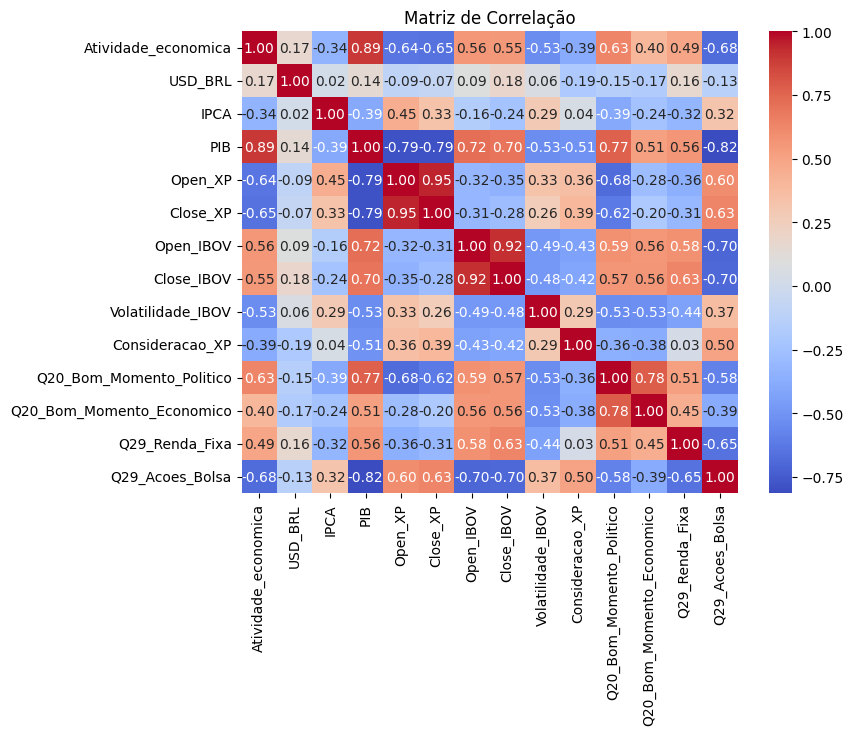

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_base, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

#M0: pib e todas

In [ ]:
df  = pd.read_excel('/content/DadosXP_AnaliseFinal.xlsx')

df = df.drop(columns=['Data', 'Atividade_economica','Close_IBOV','Open_XP','IPCA'])

lags = [1, 2, 3]

cols = ['PIB', 'Open_IBOV','Close_XP', 'USD_BRL','Volatilidade_IBOV','Q20_Bom_Momento_Politico','Q20_Bom_Momento_Economico','Q29_Acoes_Bolsa']

for col in cols:
    for lag in lags:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

df = df.dropna()

X = df.drop(columns=['Consideracao_XP'])
y = df['Consideracao_XP']

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import numpy as np

model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

tscv = TimeSeriesSplit(n_splits=5)

rmse_scores = cross_val_score(model, X, y, cv=tscv, scoring='neg_mean_squared_error')

mae_scores = cross_val_score(model, X, y, cv=tscv, scoring='neg_mean_absolute_error')

rmse = np.sqrt(-rmse_scores.mean())
mae = -mae_scores.mean()

print("RMSE:", rmse.round(2))
print("MAE:", mae.round(2))
model.fit(X, y)

RMSE: 3.1
MAE: 2.57


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(20)

,0
Open_IBOV_lag3,0.139137
Q20_Bom_Momento_Economico_lag3,0.115429
Q29_Acoes_Bolsa_lag1,0.091996
PIB_lag1,0.059165
Close_XP_lag1,0.050994
USD_BRL_lag3,0.050218
Q20_Bom_Momento_Politico_lag3,0.049813
Close_XP,0.044238
Q29_Renda_Fixa,0.037683
Volatilidade_IBOV_lag3,0.037308


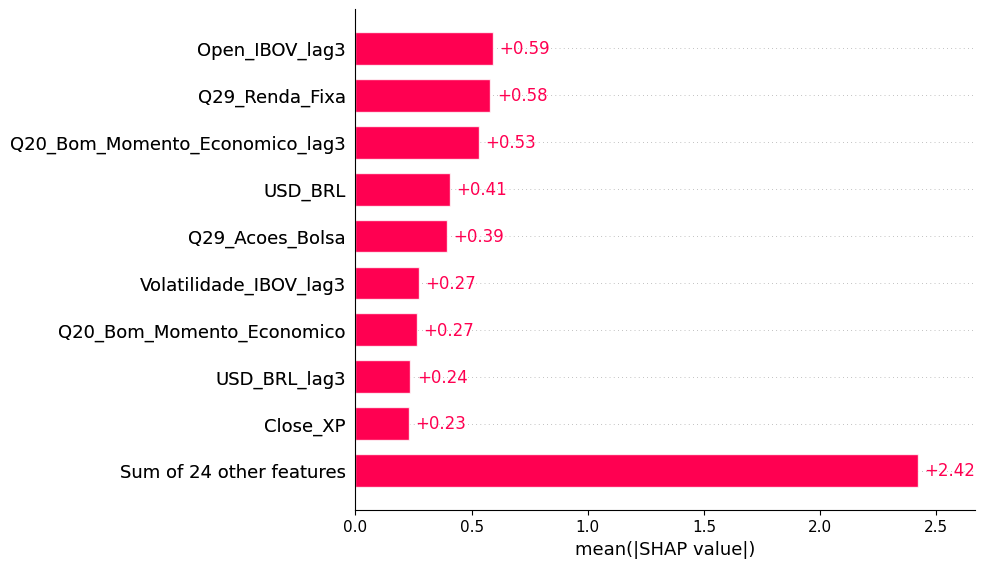

In [ ]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X)

shap.plots.bar(shap_values)



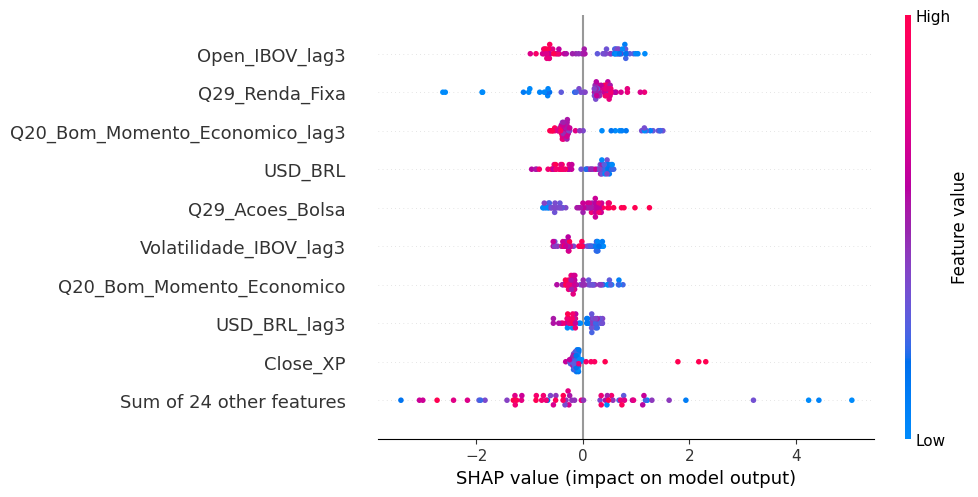

In [ ]:
shap.plots.beeswarm(shap_values)

In [ ]:
import pandas as pd
import numpy as np

shap_mean = np.abs(shap_values.values).mean(axis=0)

df_importance = pd.DataFrame({
    'variavel': X.columns,
    'impacto_medio': shap_mean
}).sort_values(by='impacto_medio', ascending=False)

df_importance["ranking"] = df_importance.index + 1

In [ ]:
df_importance['%_impacto'] = df_importance['impacto_medio'] / df_importance['impacto_medio'].sum() *100
df_importance['%_imp_acum'] = df_importance['%_impacto'].cumsum()

#df_importance.sort_values(by='ranking', ascending=True).tail() #tem 33 variaveis
df_importance.sort_values(by='%_imp_acum', ascending=False)

,variavel,impacto_medio,ranking,%_impacto,%_imp_acum
11,PIB_lag3,0.010976,12,0.185092,99.999992
27,Q20_Bom_Momento_Economico_lag1,0.021583,28,0.363955,99.814903
32,Q29_Acoes_Bolsa_lag3,0.026551,33,0.447732,99.450951
17,Close_XP_lag3,0.031915,18,0.538190,99.003220
21,Volatilidade_IBOV_lag1,0.034530,22,0.582273,98.465027
24,Q20_Bom_Momento_Politico_lag1,0.037431,25,0.631194,97.882751
13,Open_IBOV_lag2,0.045666,14,0.770061,97.251556
22,Volatilidade_IBOV_lag2,0.047910,23,0.807917,96.481499
1,PIB,0.073340,2,1.236742,95.673584
3,Open_IBOV,0.080414,4,1.356027,94.436844


# M1 = ipca + q20 + q29 + open ibov + close xp + usd + volatilidade ibov

In [ ]:
# tentativa com algumas variaveis

In [ ]:
df  = pd.read_excel('/content/DadosXP_AnaliseFinal.xlsx')

df = df.drop(columns=['Data', 'Atividade_economica','Close_IBOV','Open_XP','PIB'])

lags = [1, 2, 3]

cols = ['IPCA', 'Open_IBOV','Close_XP', 'USD_BRL','Volatilidade_IBOV','Q20_Bom_Momento_Politico','Q20_Bom_Momento_Economico','Q29_Acoes_Bolsa','Q29_Renda_Fixa']

for col in cols:
    for lag in lags:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

df = df.dropna()

In [ ]:
X = df.drop(columns=['Consideracao_XP'])
y = df['Consideracao_XP']

In [ ]:
corr_m1 = X.corr()

In [ ]:
model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

tscv = TimeSeriesSplit(n_splits=5)

rmse_scores = cross_val_score(model, X, y, cv=tscv, scoring='neg_mean_squared_error')

mae_scores = cross_val_score(model, X, y, cv=tscv, scoring='neg_mean_absolute_error')

rmse = np.sqrt(-rmse_scores.mean())
mae = -mae_scores.mean()

print("RMSE:", rmse.round(2))
print("MAE:", mae.round(2))
model.fit(X, y)

RMSE: 3.28
MAE: 2.72


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(20)

,0
Q20_Bom_Momento_Economico_lag3,0.119480
Q29_Acoes_Bolsa_lag1,0.109215
Open_IBOV_lag3,0.097656
Close_XP,0.053235
Close_XP_lag1,0.041086
USD_BRL_lag3,0.040122
Q20_Bom_Momento_Politico_lag3,0.040098
Volatilidade_IBOV_lag2,0.037857
Q29_Acoes_Bolsa,0.036656
Q29_Acoes_Bolsa_lag2,0.032890


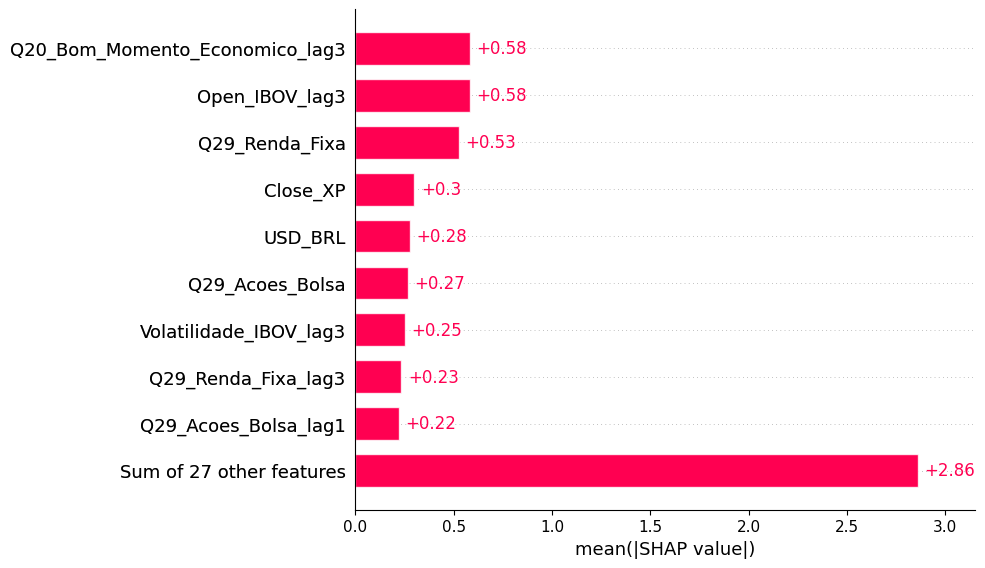

In [ ]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X)

shap.plots.bar(shap_values)



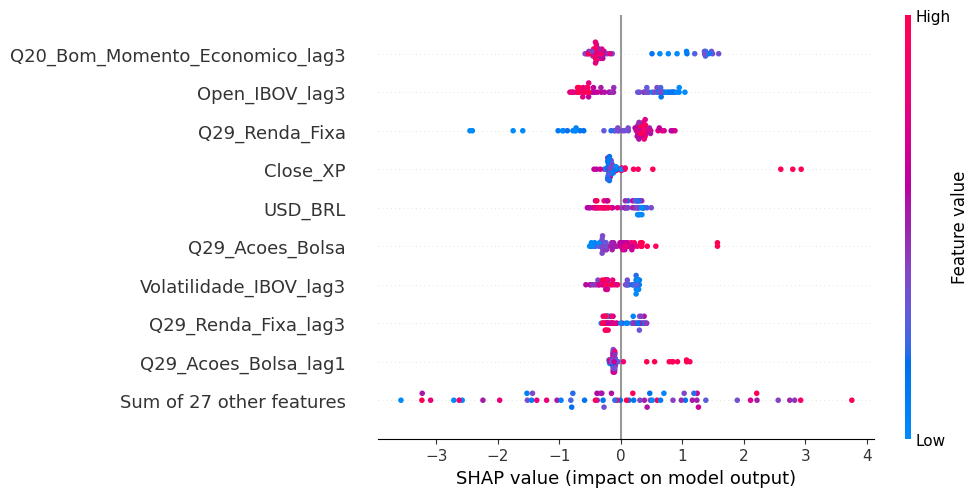

In [ ]:
shap.plots.beeswarm(shap_values)

In [ ]:
shap_mean = np.abs(shap_values.values).mean(axis=0)

df_importance_m1 = pd.DataFrame({
#    "id": df_importance.index + 1,
    'variavel': X.columns,
    'impacto_medio': shap_mean
}).sort_values(by='impacto_medio', ascending=False)



In [ ]:
df_importance_m1['%_impacto'] = df_importance_m1['impacto_medio'] / df_importance_m1['impacto_medio'].sum() *100
df_importance_m1['%_imp_acum'] = df_importance_m1['%_impacto'].cumsum()

#df_importance.sort_values(by='ranking', ascending=True).tail() #tem 33 variaveis
df_importance_m1#.sort_values(by='%_imp_acum', ascending=False)

,variavel,impacto_medio,%_impacto,%_imp_acum
29,Q20_Bom_Momento_Economico_lag3,0.582844,9.563206,9.563206
14,Open_IBOV_lag3,0.580151,9.519015,19.082222
7,Q29_Renda_Fixa,0.525340,8.619686,27.701908
2,Close_XP,0.298687,4.900805,32.602715
0,USD_BRL,0.276649,4.539219,37.141933
8,Q29_Acoes_Bolsa,0.265380,4.354310,41.496243
23,Volatilidade_IBOV_lag3,0.250691,4.113300,45.609543
35,Q29_Renda_Fixa_lag3,0.233124,3.825060,49.434605
30,Q29_Acoes_Bolsa_lag1,0.221774,3.638828,53.073433
31,Q29_Acoes_Bolsa_lag2,0.220672,3.620743,56.694176


# M2 = pib + **ipca** + q20 + q29 + open ibov + close xp + usd + volatilidade ibov

In [ ]:
df  = pd.read_excel('/content/DadosXP_AnaliseFinal.xlsx')

df = df.drop(columns=['Data', 'Atividade_economica','Close_IBOV','Open_XP'])

lags = [1, 2, 3]

cols = ['IPCA','PIB', 'Open_IBOV','Close_XP', 'USD_BRL','Volatilidade_IBOV','Q20_Bom_Momento_Politico','Q20_Bom_Momento_Economico','Q29_Acoes_Bolsa']

for col in cols:
    for lag in lags:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

df = df.dropna()

X = df.drop(columns=['Consideracao_XP'])
y = df['Consideracao_XP']

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import numpy as np

model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

tscv = TimeSeriesSplit(n_splits=5)

rmse_scores = cross_val_score(model, X, y, cv=tscv, scoring='neg_mean_squared_error')

mae_scores = cross_val_score(model, X, y, cv=tscv, scoring='neg_mean_absolute_error')

rmse = np.sqrt(-rmse_scores.mean())
mae = -mae_scores.mean()

print("RMSE:", rmse.round(2))
print("MAE:", mae.round(2))
model.fit(X, y)

RMSE: 3.3
MAE: 2.79


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(20)

,0
Q29_Acoes_Bolsa_lag1,0.140874
Q20_Bom_Momento_Economico_lag3,0.104918
Open_IBOV_lag3,0.082018
PIB_lag1,0.057054
Close_XP,0.054508
Q20_Bom_Momento_Politico_lag3,0.037713
Q20_Bom_Momento_Economico_lag2,0.036788
Q29_Acoes_Bolsa,0.031403
Close_XP_lag1,0.028507
USD_BRL_lag3,0.028153


In [ ]:
explainer = shap.Explainer(model)
shap_values = explainer(X)

#shap.plots.bar(shap_values)
#shap.plots.beeswarm(shap_values)

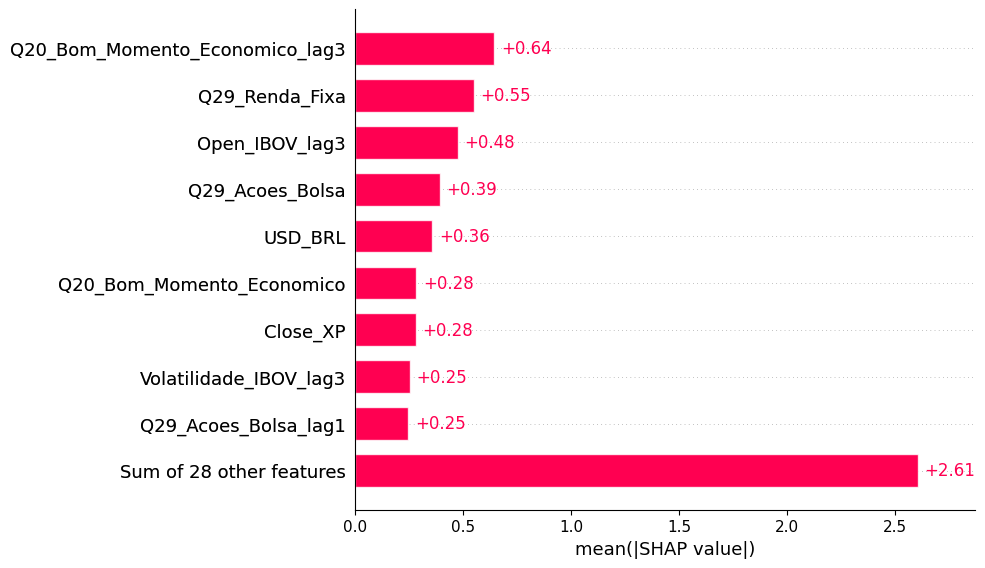

In [ ]:
shap.plots.bar(shap_values)



# M3 = atividade + ipca

In [ ]:
df  = pd.read_excel('/content/DadosXP_AnaliseFinal.xlsx')

df = df.drop(columns=['Data', 'PIB','Close_IBOV','Open_XP'])

lags = [1, 2, 3]

cols = ['IPCA','Atividade_economica', 'Open_IBOV','Close_XP', 'USD_BRL','Volatilidade_IBOV','Q20_Bom_Momento_Politico','Q20_Bom_Momento_Economico','Q29_Acoes_Bolsa']

for col in cols:
    for lag in lags:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

df = df.dropna()

X = df.drop(columns=['Consideracao_XP'])
y = df['Consideracao_XP']

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import numpy as np

model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

tscv = TimeSeriesSplit(n_splits=5)


rmse_scores = cross_val_score(model, X, y, cv=tscv, scoring='neg_mean_squared_error')

mae_scores = cross_val_score(model, X, y, cv=tscv, scoring='neg_mean_absolute_error')

rmse = np.sqrt(-rmse_scores.mean())
mae = -mae_scores.mean()


print("RMSE:", rmse.round(2))
print("MAE:", mae.round(2))
model.fit(X, y)

RMSE: 3.18
MAE: 2.64


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

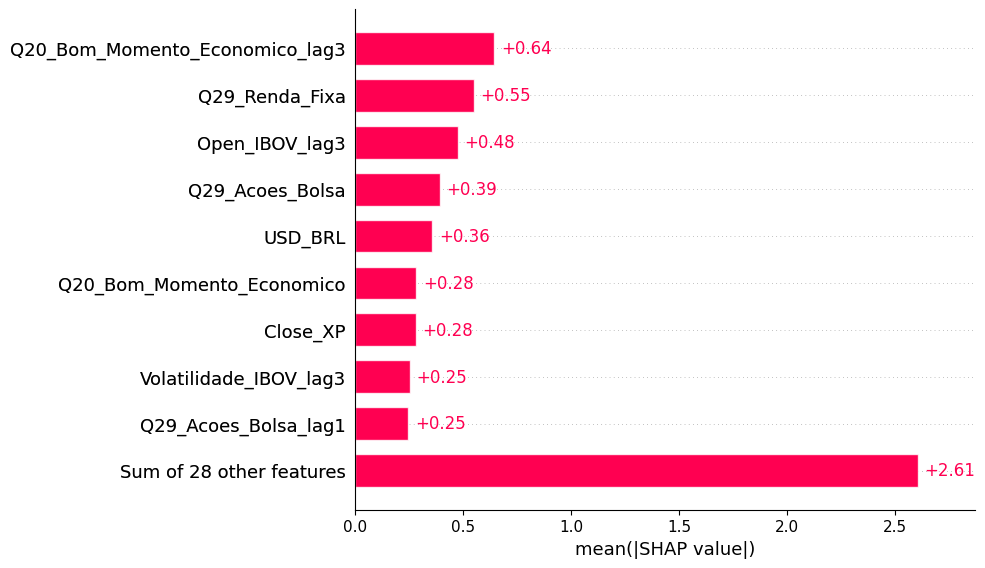

In [ ]:
shap.plots.bar(shap_values)


# M4 = M1 sem irrelevantes

In [ ]:
df  = pd.read_excel('/content/DadosXP_AnaliseFinal.xlsx')

df = df.drop(columns=['Data', 'Atividade_economica','Close_IBOV','Open_XP','PIB'])

lags = [1, 2, 3]

cols = ['IPCA', 'Open_IBOV','Close_XP', 'USD_BRL','Volatilidade_IBOV','Q20_Bom_Momento_Politico','Q20_Bom_Momento_Economico','Q29_Acoes_Bolsa','Q29_Renda_Fixa']

for col in cols:
    for lag in lags:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

df = df.dropna()

X = df.drop(columns=['Consideracao_XP', 'Open_IBOV_lag1','IPCA_lag2','Open_IBOV_lag2','USD_BRL_lag1',
                     'Q29_Renda_Fixa_lag2','Close_XP_lag3','Volatilidade_IBOV_lag1','Q20_Bom_Momento_Politico_lag2',
                     'Open_IBOV','IPCA_lag1','Q29_Acoes_Bolsa_lag3',
                     'Q20_Bom_Momento_Economico_lag1','Q20_Bom_Momento_Politico_lag1'])
y = df['Consideracao_XP']

In [ ]:
corr_m1_sem = X.corr()

In [ ]:
model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

tscv = TimeSeriesSplit(n_splits=5)


rmse_scores = cross_val_score(model, X, y, cv=tscv, scoring='neg_mean_squared_error')

mae_scores = cross_val_score(model, X, y, cv=tscv, scoring='neg_mean_absolute_error')

rmse = np.sqrt(-rmse_scores.mean())
mae = -mae_scores.mean()

print("RMSE:", rmse.round(2))
print("MAE:", mae.round(2))
model.fit(X, y)

RMSE: 3.17
MAE: 2.62


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
explainer = shap.Explainer(model)
shap_values = explainer(X)

shap_mean = np.abs(shap_values.values).mean(axis=0)

df_importance_m2 = pd.DataFrame({
    'variavel': X.columns,
    'impacto_medio': shap_mean
}).sort_values(by='impacto_medio', ascending=False)

In [ ]:
df_importance_m2['%_impacto'] = df_importance_m2['impacto_medio'] / df_importance_m2['impacto_medio'].sum() *100
df_importance_m2['%_imp_acum'] = df_importance_m2['%_impacto'].cumsum()

#df_importance.sort_values(by='ranking', ascending=True).tail() #tem 33 variaveis
df_importance_m2#.sort_values(by='%_imp_acum', ascending=True)

,variavel,impacto_medio,%_impacto,%_imp_acum
9,Open_IBOV_lag3,0.727679,12.773849,12.773849
18,Q20_Bom_Momento_Economico_lag3,0.608992,10.690381,23.464230
6,Q29_Renda_Fixa,0.450326,7.905118,31.369347
7,Q29_Acoes_Bolsa,0.352233,6.183186,37.552532
20,Q29_Acoes_Bolsa_lag2,0.322552,5.662158,43.214691
0,USD_BRL,0.315471,5.537855,48.752548
2,Close_XP,0.295771,5.192037,53.944584
19,Q29_Acoes_Bolsa_lag1,0.290714,5.103261,59.047844
22,Q29_Renda_Fixa_lag3,0.267695,4.699183,63.747028
15,Volatilidade_IBOV_lag3,0.240296,4.218211,67.965240


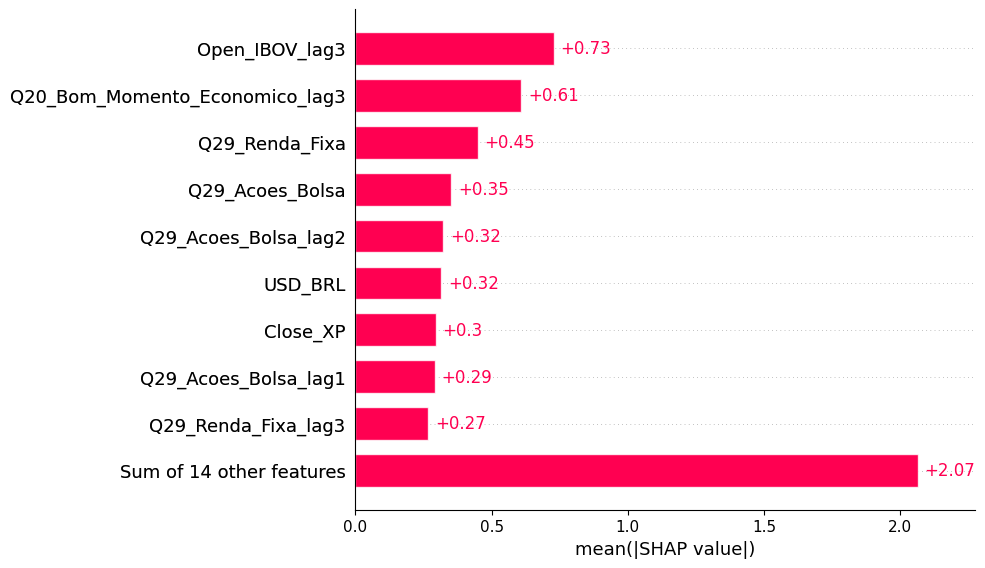

In [ ]:
shap.plots.bar(shap_values)


In [ ]:
df_imp2 = df_importance.copy()

df_imp2['variavel_base'] = df_imp2['variavel'].str.replace(r'_lag\d+', '', regex=True)

df_imp2_agg = df_imp2.groupby('variavel_base')['%_impacto'].sum().reset_index()

df_imp2_agg = df_imp2_agg.sort_values(by='%_impacto', ascending=False)


df_imp2_agg['%_impacto'] = df_imp2_agg['%_impacto'] / df_imp2_agg['%_impacto'].sum() *100
df_imp2_agg


,variavel_base,%_impacto
3,Q20_Bom_Momento_Economico,17.437120
2,Open_IBOV,15.928331
7,USD_BRL,13.031498
6,Q29_Renda_Fixa,10.969119
0,Close_XP,10.857846
5,Q29_Acoes_Bolsa,10.093710
1,IPCA,8.406113
4,Q20_Bom_Momento_Politico,7.831594
8,Volatilidade_IBOV,5.444670


# Envio

In [ ]:
corr_base

,Atividade_economica,USD_BRL,IPCA,PIB,Open_XP,Close_XP,Open_IBOV,Close_IBOV,Volatilidade_IBOV,Consideracao_XP,Q20_Bom_Momento_Politico,Q20_Bom_Momento_Economico,Q29_Renda_Fixa,Q29_Acoes_Bolsa
Atividade_economica,1.000000,0.165985,-0.339399,0.893684,-0.644230,-0.652805,0.557047,0.549623,-0.534579,-0.388766,0.633754,0.397484,0.492995,-0.682291
USD_BRL,0.165985,1.000000,0.021080,0.144530,-0.093405,-0.070439,0.091597,0.178338,0.062922,-0.193633,-0.146286,-0.172427,0.160375,-0.127763
IPCA,-0.339399,0.021080,1.000000,-0.394122,0.452690,0.332732,-0.160629,-0.238215,0.285978,0.044129,-0.392479,-0.241038,-0.322518,0.322446
PIB,0.893684,0.144530,-0.394122,1.000000,-0.791609,-0.790579,0.721855,0.701483,-0.533788,-0.509869,0.771281,0.511266,0.564574,-0.815421
Open_XP,-0.644230,-0.093405,0.452690,-0.791609,1.000000,0.947705,-0.317724,-0.346590,0.329704,0.360338,-0.681413,-0.283174,-0.358568,0.598408
Close_XP,-0.652805,-0.070439,0.332732,-0.790579,0.947705,1.000000,-0.314782,-0.278037,0.259062,0.394897,-0.622648,-0.196634,-0.306055,0.633227
Open_IBOV,0.557047,0.091597,-0.160629,0.721855,-0.317724,-0.314782,1.000000,0.918361,-0.487741,-0.434102,0.585201,0.560280,0.581681,-0.704083
Close_IBOV,0.549623,0.178338,-0.238215,0.701483,-0.346590,-0.278037,0.918361,1.000000,-0.483067,-0.415066,0.566153,0.563391,0.634325,-0.695337
Volatilidade_IBOV,-0.534579,0.062922,0.285978,-0.533788,0.329704,0.259062,-0.487741,-0.483067,1.000000,0.291802,-0.533394,-0.527521,-0.437218,0.367131
Consideracao_XP,-0.388766,-0.193633,0.044129,-0.509869,0.360338,0.394897,-0.434102,-0.415066,0.291802,1.000000,-0.357368,-0.376461,0.031192,0.498450


In [ ]:
corr_m1

,USD_BRL,IPCA,Close_XP,Open_IBOV,Volatilidade_IBOV,Q20_Bom_Momento_Politico,Q20_Bom_Momento_Economico,Q29_Renda_Fixa,Q29_Acoes_Bolsa,IPCA_lag1,...,Volatilidade_IBOV_lag3,Q20_Bom_Momento_Politico_lag1,Q20_Bom_Momento_Politico_lag2,Q20_Bom_Momento_Politico_lag3,Q20_Bom_Momento_Economico_lag1,Q20_Bom_Momento_Economico_lag2,Q20_Bom_Momento_Economico_lag3,Q29_Acoes_Bolsa_lag1,Q29_Acoes_Bolsa_lag2,Q29_Acoes_Bolsa_lag3
USD_BRL,1.000000,0.020840,-0.087128,0.103879,0.059826,-0.147906,-0.172156,0.159694,-0.132070,0.042402,...,-0.090656,-0.100675,0.021587,0.054096,-0.125997,-0.021614,0.102973,-0.202241,-0.197686,-0.209854
IPCA,0.020840,1.000000,0.398912,-0.183230,0.299369,-0.434201,-0.258553,-0.332363,0.336777,0.475989,...,0.232436,-0.407873,-0.429761,-0.277968,-0.219400,-0.209820,-0.145964,0.391300,0.357886,0.385396
Close_XP,-0.087128,0.398912,1.000000,-0.216167,0.205057,-0.564585,-0.100492,-0.329716,0.636394,0.371091,...,0.293909,-0.569522,-0.563699,-0.608218,-0.122635,-0.129047,-0.198552,0.653672,0.678169,0.653321
Open_IBOV,0.103879,-0.183230,-0.216167,1.000000,-0.461769,0.539512,0.521403,0.615168,-0.702335,-0.272023,...,-0.552409,0.571357,0.503554,0.461523,0.582885,0.528352,0.428020,-0.650247,-0.642830,-0.641038
Volatilidade_IBOV,0.059826,0.299369,0.205057,-0.461769,1.000000,-0.509449,-0.505725,-0.445797,0.349591,0.194998,...,0.305269,-0.398985,-0.362758,-0.477597,-0.322695,-0.259085,-0.319085,0.389452,0.430829,0.419954
Q20_Bom_Momento_Politico,-0.147906,-0.434201,-0.564585,0.539512,-0.509449,1.000000,0.765175,0.543891,-0.570853,-0.443580,...,-0.433716,0.786890,0.665652,0.621874,0.606804,0.437460,0.335442,-0.584804,-0.651187,-0.672930
Q20_Bom_Momento_Economico,-0.172156,-0.258553,-0.100492,0.521403,-0.505725,0.765175,1.000000,0.477441,-0.368760,-0.314655,...,-0.422672,0.538990,0.403690,0.408413,0.624021,0.375863,0.316361,-0.408396,-0.486594,-0.472260
Q29_Renda_Fixa,0.159694,-0.332363,-0.329716,0.615168,-0.445797,0.543891,0.477441,1.000000,-0.625422,-0.383104,...,-0.417858,0.563364,0.502172,0.454104,0.469788,0.418587,0.291229,-0.636005,-0.646595,-0.687849
Q29_Acoes_Bolsa,-0.132070,0.336777,0.636394,-0.702335,0.349591,-0.570853,-0.368760,-0.625422,1.000000,0.400797,...,0.629519,-0.658246,-0.684248,-0.672566,-0.491885,-0.534411,-0.499936,0.840517,0.792477,0.737161
IPCA_lag1,0.042402,0.475989,0.371091,-0.272023,0.194998,-0.443580,-0.314655,-0.383104,0.400797,1.000000,...,0.253065,-0.429552,-0.404859,-0.429228,-0.258282,-0.216032,-0.207178,0.339543,0.399647,0.360595


In [ ]:
corr_m1_sem

,USD_BRL,IPCA,Close_XP,Q20_Bom_Momento_Politico,Q20_Bom_Momento_Economico,Q29_Renda_Fixa,Q29_Acoes_Bolsa,IPCA_lag2,IPCA_lag3,Open_IBOV_lag1,Open_IBOV_lag3,Close_XP_lag1,Close_XP_lag2,USD_BRL_lag1,USD_BRL_lag3,Volatilidade_IBOV_lag3,Q20_Bom_Momento_Politico_lag3,Q20_Bom_Momento_Economico_lag2,Q20_Bom_Momento_Economico_lag3,Q29_Acoes_Bolsa_lag1
USD_BRL,1.000000,0.020840,-0.087128,-0.147906,-0.172156,0.159694,-0.132070,0.043108,0.022581,0.179648,0.375146,-0.116540,-0.038495,0.820887,0.472069,-0.090656,0.054096,-0.021614,0.102973,-0.202241
IPCA,0.020840,1.000000,0.398912,-0.434201,-0.258553,-0.332363,0.336777,0.380976,0.142102,-0.187137,-0.249709,0.522507,0.497939,0.200444,0.291450,0.232436,-0.277968,-0.209820,-0.145964,0.391300
Close_XP,-0.087128,0.398912,1.000000,-0.564585,-0.100492,-0.329716,0.636394,0.319113,0.321307,-0.267121,-0.414634,0.941996,0.885933,-0.050030,0.067628,0.293909,-0.608218,-0.129047,-0.198552,0.653672
Q20_Bom_Momento_Politico,-0.147906,-0.434201,-0.564585,1.000000,0.765175,0.543891,-0.570853,-0.349298,-0.284648,0.485882,0.424494,-0.629581,-0.719239,-0.110228,-0.020349,-0.433716,0.621874,0.437460,0.335442,-0.584804
Q20_Bom_Momento_Economico,-0.172156,-0.258553,-0.100492,0.765175,1.000000,0.477441,-0.368760,-0.183403,-0.133771,0.423188,0.378011,-0.197801,-0.310202,-0.077910,-0.006000,-0.422672,0.408413,0.375863,0.316361,-0.408396
Q29_Renda_Fixa,0.159694,-0.332363,-0.329716,0.543891,0.477441,1.000000,-0.625422,-0.297495,-0.247981,0.568796,0.475154,-0.390492,-0.441177,0.117014,0.087005,-0.417858,0.454104,0.418587,0.291229,-0.636005
Q29_Acoes_Bolsa,-0.132070,0.336777,0.636394,-0.570853,-0.368760,-0.625422,1.000000,0.475453,0.429485,-0.709755,-0.698277,0.593622,0.565646,-0.052628,-0.022840,0.629519,-0.672566,-0.534411,-0.499936,0.840517
IPCA_lag2,0.043108,0.380976,0.319113,-0.349298,-0.183403,-0.297495,0.475453,1.000000,0.468635,-0.250420,-0.152888,0.342257,0.350502,0.043080,0.199924,0.309125,-0.382015,-0.243693,-0.192118,0.394611
IPCA_lag3,0.022581,0.142102,0.321307,-0.284648,-0.133771,-0.247981,0.429485,0.468635,1.000000,-0.273060,-0.120173,0.299205,0.306930,0.046947,0.025578,0.286066,-0.376820,-0.268615,-0.215809,0.463895
Open_IBOV_lag1,0.179648,-0.187137,-0.267121,0.485882,0.423188,0.568796,-0.709755,-0.250420,-0.273060,1.000000,0.780131,-0.248617,-0.249473,0.087356,0.278107,-0.650467,0.485166,0.559433,0.499601,-0.667738


In [ ]:
with pd.ExcelWriter('v3_analiseXP_abr26.xlsx') as writer:
    corr_base.to_excel(writer, sheet_name='Correlacao Q20 e Q29', index=False)
    df_imp2_agg.to_excel(writer, sheet_name = 'v3 - Resumo Variaveis e Impacto')
    df_importance_m2.to_excel(writer, sheet_name='v3 - Variaveis e Impacto', index=False)
    corr_m1_sem.to_excel(writer, sheet_name='v3 - Correlacao')


In [ ]:
import numpy as np

lags = range(0, 6)

corrs = []

for lag in lags:
    corr = df['Consideracao_XP'].corr(df['Open_IBOV'].shift(lag))
    corrs.append(corr)

for lag, corr in zip(lags, corrs):
    print(f"Lag {lag}: {corr:.3f}")